# CR 1-4 Prediction Error Analysis

This notebook analyzes what distinguishes good predictions from bad ones for CR 1-4 monsters,
and examines differences between over-predictions and under-predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import os

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 200)

# Detect execution context
if os.path.exists('../data'):
    DATA_DIR = '../data'
else:
    DATA_DIR = 'data'

print(f"Data directory: {DATA_DIR}")

Data directory: ../data


In [2]:
# Load engineered features (contains predictions)
features_df = pd.read_csv(f'{DATA_DIR}/engineered_features.csv')

# Load original data for traits/actions
original_df = pd.read_csv(f'{DATA_DIR}/dnd5e_monsters_from_json.csv')
original_df = original_df[original_df['Source_Name'] == 'Free Basic Rules (2014)'].copy()

# Load archetype scores
archetypes_df = pd.read_csv(f'{DATA_DIR}/creature_archetypes.csv')

# Merge to get traits/actions with predictions
df = features_df.merge(original_df[['Name', 'Traits', 'Actions', 'Reactions', 'Legendary_Actions', 'Bonus_Actions']], 
                       on='Name', how='left')

# Merge archetype scores
archetype_cols = ['boss_score', 'lieutenant_score', 'minion_score', 'solo_challenge_score', 
                  'enhanced_version_score', 'brute_score', 'tank_score', 'skirmisher_score', 
                  'spellcaster_score', 'controller_score', 'ambusher_score', 'swarm_score', 'archetypes']
df = df.merge(archetypes_df[['Name'] + archetype_cols], on='Name', how='left')

# Filter to CR 1-4 only
df_cr1_4 = df[(df['cr_numeric'] >= 1.0) & (df['cr_numeric'] <= 4.0)].copy()

print(f"Total CR 1-4 monsters: {len(df_cr1_4)}")
print(f"Columns available: {len(df_cr1_4.columns)}")
print(f"\nArchetype columns loaded: {[c for c in archetype_cols if c in df_cr1_4.columns]}")

Total CR 1-4 monsters: 99
Columns available: 97

Archetype columns loaded: ['boss_score', 'lieutenant_score', 'minion_score', 'solo_challenge_score', 'enhanced_version_score', 'brute_score', 'tank_score', 'skirmisher_score', 'spellcaster_score', 'controller_score', 'ambusher_score', 'swarm_score', 'archetypes']


In [3]:
# Calculate error metrics
df_cr1_4['abs_error'] = np.abs(df_cr1_4['hp_delta'])
df_cr1_4['abs_pct_error'] = np.abs(df_cr1_4['hp_delta_pct'])

# Classify predictions
df_cr1_4['prediction_quality'] = np.where(df_cr1_4['abs_pct_error'] < 10, 'Good (<10%)', 'Bad (>=10%)')
df_cr1_4['prediction_direction'] = np.where(df_cr1_4['hp_delta'] > 0, 'Over-predicted', 
                                            np.where(df_cr1_4['hp_delta'] < 0, 'Under-predicted', 'Exact'))

print("📊 PREDICTION QUALITY DISTRIBUTION")
print("=" * 50)
quality_counts = df_cr1_4['prediction_quality'].value_counts()
print(quality_counts)
print(f"\nGood prediction rate: {(quality_counts.get('Good (<10%)', 0) / len(df_cr1_4) * 100):.1f}%")

print("\n📊 PREDICTION DIRECTION DISTRIBUTION")
print("=" * 50)
direction_counts = df_cr1_4['prediction_direction'].value_counts()
print(direction_counts)

📊 PREDICTION QUALITY DISTRIBUTION
prediction_quality
Bad (>=10%)    76
Good (<10%)    23
Name: count, dtype: int64

Good prediction rate: 23.2%

📊 PREDICTION DIRECTION DISTRIBUTION
prediction_direction
Over-predicted     54
Under-predicted    45
Name: count, dtype: int64


## Part 1: Good vs Bad Predictions Analysis

In [4]:
# Split into good and bad predictions
good_pred = df_cr1_4[df_cr1_4['prediction_quality'] == 'Good (<10%)'].copy()
bad_pred = df_cr1_4[df_cr1_4['prediction_quality'] == 'Bad (>=10%)'].copy()

print(f"Good predictions: {len(good_pred)} monsters")
print(f"Bad predictions: {len(bad_pred)} monsters")

Good predictions: 23 monsters
Bad predictions: 76 monsters


In [5]:
# Engineered features to compare
numeric_features = [
    # Combat stats
    'actual_hp', 'ac_value', 'highest_attack_bonus', 'highest_save_dc', 'estimated_dpr',
    
    # Deviations from baseline
    'ac_deviation', 'attack_deviation', 'dpr_deviation', 'save_dc_deviation',
    
    # Movement
    'speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb',
    'movement_types_count', 'has_flying',
    
    # Defenses
    'save_proficiency_count', 'skill_proficiency_count',
    'resistance_count', 'immunity_count', 'vulnerability_count', 'condition_immunity_count',
    
    # Senses
    'has_darkvision', 'darkvision_deviation', 'has_blindsight', 'has_truesight', 'has_tremorsense',
    
    # Abilities count
    'trait_count', 'action_count', 'reaction_count', 'bonus_action_count',
    'legendary_action_count', 'total_ability_count',
    
    # Special abilities
    'has_legendary_resistance', 'has_magic_resistance', 'has_regeneration',
    'has_spellcasting', 'spellcaster_level', 'has_grapple',
    
    # Conditions
    'inflicts_poisoned', 'inflicts_blinded', 'inflicts_charmed', 'inflicts_frightened',
    'inflicts_paralyzed', 'inflicts_petrified', 'inflicts_prone', 'inflicts_restrained', 'inflicts_stunned'
]

# Filter to features that exist in the dataframe
numeric_features = [f for f in numeric_features if f in df_cr1_4.columns]

print(f"Comparing {len(numeric_features)} features between good and bad predictions")

Comparing 48 features between good and bad predictions


In [6]:
print("📊 ENGINEERED FEATURES: GOOD vs BAD PREDICTIONS")
print("=" * 80)
print(f"{'Feature':<35} {'Good Mean':>12} {'Bad Mean':>12} {'Diff':>10} {'p-value':>10}")
print("-" * 80)

significant_features = []

for feature in numeric_features:
    good_vals = good_pred[feature].dropna()
    bad_vals = bad_pred[feature].dropna()
    
    if len(good_vals) > 0 and len(bad_vals) > 0:
        good_mean = good_vals.mean()
        bad_mean = bad_vals.mean()
        diff = bad_mean - good_mean
        
        # Statistical test
        if good_vals.std() > 0 or bad_vals.std() > 0:
            _, p_value = stats.mannwhitneyu(good_vals, bad_vals, alternative='two-sided')
        else:
            p_value = 1.0
        
        sig_marker = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else ''
        
        if p_value < 0.1:
            significant_features.append((feature, good_mean, bad_mean, diff, p_value))
        
        print(f"{feature:<35} {good_mean:>12.2f} {bad_mean:>12.2f} {diff:>+10.2f} {p_value:>8.4f} {sig_marker}")

print("\n*** p<0.01, ** p<0.05, * p<0.1")

📊 ENGINEERED FEATURES: GOOD vs BAD PREDICTIONS
Feature                                Good Mean     Bad Mean       Diff    p-value
--------------------------------------------------------------------------------
actual_hp                                  51.87        48.47      -3.40   0.4678 
ac_value                                   13.13        13.32      +0.19   0.7982 
highest_attack_bonus                        5.17         4.99      -0.19   0.3944 
highest_save_dc                             7.52         8.22      +0.70   0.5003 
estimated_dpr                              15.14        14.22      -0.92   0.2275 
ac_deviation                                0.26         0.43      +0.17   0.8569 
attack_deviation                            0.04        -0.14      -0.19   0.4036 
dpr_deviation                              -3.82        -4.01      -0.19   0.7654 
save_dc_deviation                          -0.26        -0.13      +0.13   0.6730 
speed_ground                             

In [7]:
print("\n📊 MOST SIGNIFICANT DIFFERENCES (Good vs Bad)")
print("=" * 80)

if significant_features:
    significant_features.sort(key=lambda x: x[4])  # Sort by p-value
    
    for feature, good_mean, bad_mean, diff, p_value in significant_features[:15]:
        direction = "higher" if diff > 0 else "lower"
        print(f"\n{feature}:")
        print(f"   Good predictions: {good_mean:.2f}")
        print(f"   Bad predictions:  {bad_mean:.2f} ({direction} by {abs(diff):.2f})")
        print(f"   p-value: {p_value:.4f}")
else:
    print("No significant differences found at p<0.1 level")


📊 MOST SIGNIFICANT DIFFERENCES (Good vs Bad)

has_tremorsense:
   Good predictions: 0.04
   Bad predictions:  0.00 (lower by 0.04)
   p-value: 0.0728

inflicts_petrified:
   Good predictions: 0.04
   Bad predictions:  0.00 (lower by 0.04)
   p-value: 0.0728


In [8]:
# Show the worst predictions
print("\n📊 WORST 15 PREDICTIONS (highest % error)")
print("=" * 100)

worst = df_cr1_4.nlargest(15, 'abs_pct_error')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 
                                                'hp_delta', 'hp_delta_pct']].copy()
worst['hp_delta'] = worst['hp_delta'].round(1)
worst['hp_delta_pct'] = worst['hp_delta_pct'].round(1)
worst['predicted_hp'] = worst['predicted_hp'].round(1)

for _, row in worst.iterrows():
    direction = "OVER" if row['hp_delta'] > 0 else "UNDER"
    print(f"{row['Name']:<25} CR {row['cr_numeric']:<4} Actual: {row['actual_hp']:>3} HP  Pred: {row['predicted_hp']:>6} HP  Error: {row['hp_delta_pct']:>+6.1f}% ({direction})")


📊 WORST 15 PREDICTIONS (highest % error)
Quasit                    CR 1.0  Actual:   7 HP  Pred:   18.9 HP  Error: +169.6% (OVER)
Hippogriff                CR 1.0  Actual:  19 HP  Pred:   40.1 HP  Error: +111.1% (OVER)
Phase Spider              CR 3.0  Actual:  32 HP  Pred:   63.6 HP  Error:  +98.7% (OVER)
Imp                       CR 1.0  Actual:  10 HP  Pred:    0.9 HP  Error:  -91.0% (UNDER)
Giant Vulture             CR 1.0  Actual:  22 HP  Pred:   40.7 HP  Error:  +85.1% (OVER)
Ghoul                     CR 1.0  Actual:  22 HP  Pred:   38.6 HP  Error:  +75.6% (OVER)
Wererat                   CR 2.0  Actual:  33 HP  Pred:   57.4 HP  Error:  +74.0% (OVER)
Animated Armor            CR 1.0  Actual:  33 HP  Pred:   10.4 HP  Error:  -68.4% (UNDER)
Black Dragon Wyrmling     CR 2.0  Actual:  33 HP  Pred:   53.8 HP  Error:  +63.0% (OVER)
Giant Spider              CR 1.0  Actual:  26 HP  Pred:   12.1 HP  Error:  -53.4% (UNDER)
Bronze Dragon Wyrmling    CR 2.0  Actual:  32 HP  Pred:   47.3 HP

In [9]:
# Show the best predictions
print("\n📊 BEST 15 PREDICTIONS (lowest % error)")
print("=" * 100)

best = df_cr1_4.nsmallest(15, 'abs_pct_error')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 
                                                'hp_delta', 'hp_delta_pct']].copy()
best['hp_delta'] = best['hp_delta'].round(1)
best['hp_delta_pct'] = best['hp_delta_pct'].round(1)
best['predicted_hp'] = best['predicted_hp'].round(1)

for _, row in best.iterrows():
    print(f"{row['Name']:<25} CR {row['cr_numeric']:<4} Actual: {row['actual_hp']:>3} HP  Pred: {row['predicted_hp']:>6} HP  Error: {row['hp_delta_pct']:>+6.1f}%")


📊 BEST 15 PREDICTIONS (lowest % error)
Basilisk                  CR 3.0  Actual:  52 HP  Pred:   52.0 HP  Error:   +0.0%
Ankheg                    CR 2.0  Actual:  39 HP  Pred:   38.9 HP  Error:   -0.1%
Ogre                      CR 2.0  Actual:  59 HP  Pred:   59.3 HP  Error:   +0.5%
Harpy                     CR 1.0  Actual:  38 HP  Pred:   38.5 HP  Error:   +1.3%
Rhinoceros                CR 2.0  Actual:  45 HP  Pred:   44.2 HP  Error:   -1.8%
Tiger                     CR 1.0  Actual:  37 HP  Pred:   37.9 HP  Error:   +2.4%
Ettin                     CR 4.0  Actual:  85 HP  Pred:   82.8 HP  Error:   -2.6%
Giant Elk                 CR 2.0  Actual:  42 HP  Pred:   40.8 HP  Error:   -2.8%
Killer Whale              CR 3.0  Actual:  90 HP  Pred:   86.9 HP  Error:   -3.5%
Gold Dragon Wyrmling      CR 3.0  Actual:  60 HP  Pred:   62.3 HP  Error:   +3.8%
Black Pudding             CR 4.0  Actual:  85 HP  Pred:   81.4 HP  Error:   -4.2%
Giant Hyena               CR 1.0  Actual:  45 HP  Pred:   

## Part 2: Over-predictions vs Under-predictions Analysis

In [10]:
# Split into over and under predictions
over_pred = df_cr1_4[df_cr1_4['hp_delta'] > 0].copy()
under_pred = df_cr1_4[df_cr1_4['hp_delta'] < 0].copy()

print(f"Over-predictions (predicted > actual): {len(over_pred)} monsters")
print(f"Under-predictions (predicted < actual): {len(under_pred)} monsters")
print(f"\nMean over-prediction: +{over_pred['hp_delta'].mean():.1f} HP (+{over_pred['hp_delta_pct'].mean():.1f}%)")
print(f"Mean under-prediction: {under_pred['hp_delta'].mean():.1f} HP ({under_pred['hp_delta_pct'].mean():.1f}%)")

Over-predictions (predicted > actual): 54 monsters
Under-predictions (predicted < actual): 45 monsters

Mean over-prediction: +10.7 HP (+31.2%)
Mean under-prediction: -12.8 HP (-24.3%)


In [11]:
print("\n📊 ENGINEERED FEATURES: OVER vs UNDER PREDICTIONS")
print("=" * 80)
print(f"{'Feature':<35} {'Over Mean':>12} {'Under Mean':>12} {'Diff':>10} {'p-value':>10}")
print("-" * 80)

significant_direction = []

for feature in numeric_features:
    over_vals = over_pred[feature].dropna()
    under_vals = under_pred[feature].dropna()
    
    if len(over_vals) > 0 and len(under_vals) > 0:
        over_mean = over_vals.mean()
        under_mean = under_vals.mean()
        diff = over_mean - under_mean
        
        # Statistical test
        if over_vals.std() > 0 or under_vals.std() > 0:
            _, p_value = stats.mannwhitneyu(over_vals, under_vals, alternative='two-sided')
        else:
            p_value = 1.0
        
        sig_marker = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else ''
        
        if p_value < 0.1:
            significant_direction.append((feature, over_mean, under_mean, diff, p_value))
        
        print(f"{feature:<35} {over_mean:>12.2f} {under_mean:>12.2f} {diff:>+10.2f} {p_value:>8.4f} {sig_marker}")

print("\n*** p<0.01, ** p<0.05, * p<0.1")


📊 ENGINEERED FEATURES: OVER vs UNDER PREDICTIONS
Feature                                Over Mean   Under Mean       Diff    p-value
--------------------------------------------------------------------------------
actual_hp                                  42.11        57.84     -15.73   0.0003 ***
ac_value                                   13.43        13.09      +0.34   0.8953 
highest_attack_bonus                        4.83         5.27      -0.43   0.0166 **
highest_save_dc                             8.00         8.13      -0.13   0.1659 
estimated_dpr                              13.00        16.14      -3.14   0.0303 **
ac_deviation                                0.59         0.16      +0.44   0.7114 
attack_deviation                           -0.30         0.13      -0.43   0.0160 **
dpr_deviation                              -5.27        -2.39      -2.88   0.1839 
save_dc_deviation                          -0.63         0.40      -1.03   0.0000 ***
speed_ground              

In [12]:
print("\n📊 MOST SIGNIFICANT DIFFERENCES (Over vs Under predictions)")
print("=" * 80)

if significant_direction:
    significant_direction.sort(key=lambda x: x[4])  # Sort by p-value
    
    for feature, over_mean, under_mean, diff, p_value in significant_direction[:15]:
        direction = "higher in over-pred" if diff > 0 else "higher in under-pred"
        print(f"\n{feature}:")
        print(f"   Over-predictions:  {over_mean:.2f}")
        print(f"   Under-predictions: {under_mean:.2f} ({direction} by {abs(diff):.2f})")
        print(f"   p-value: {p_value:.4f}")
else:
    print("No significant differences found at p<0.1 level")


📊 MOST SIGNIFICANT DIFFERENCES (Over vs Under predictions)

save_dc_deviation:
   Over-predictions:  -0.63
   Under-predictions: 0.40 (higher in under-pred by 1.03)
   p-value: 0.0000

actual_hp:
   Over-predictions:  42.11
   Under-predictions: 57.84 (higher in under-pred by 15.73)
   p-value: 0.0003

attack_deviation:
   Over-predictions:  -0.30
   Under-predictions: 0.13 (higher in under-pred by 0.43)
   p-value: 0.0160

highest_attack_bonus:
   Over-predictions:  4.83
   Under-predictions: 5.27 (higher in under-pred by 0.43)
   p-value: 0.0166

estimated_dpr:
   Over-predictions:  13.00
   Under-predictions: 16.14 (higher in under-pred by 3.14)
   p-value: 0.0303

resistance_count:
   Over-predictions:  1.09
   Under-predictions: 0.27 (higher in over-pred by 0.83)
   p-value: 0.0743


In [13]:
# Show worst over-predictions
print("\n📊 TOP 10 OVER-PREDICTIONS (model thinks they should have more HP)")
print("=" * 100)

worst_over = over_pred.nlargest(10, 'hp_delta')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 
                                                 'hp_delta', 'hp_delta_pct']].copy()
for _, row in worst_over.iterrows():
    print(f"{row['Name']:<25} CR {row['cr_numeric']:<4} Actual: {row['actual_hp']:>3} HP  Pred: {row['predicted_hp']:>6.1f} HP  Error: +{row['hp_delta']:.1f} HP (+{row['hp_delta_pct']:.1f}%)")


📊 TOP 10 OVER-PREDICTIONS (model thinks they should have more HP)
Phase Spider              CR 3.0  Actual:  32 HP  Pred:   63.6 HP  Error: +31.6 HP (+98.7%)
Elephant                  CR 4.0  Actual:  76 HP  Pred:  106.7 HP  Error: +30.7 HP (+40.4%)
Wereboar                  CR 4.0  Actual:  78 HP  Pred:  102.4 HP  Error: +24.4 HP (+31.3%)
Wererat                   CR 2.0  Actual:  33 HP  Pred:   57.4 HP  Error: +24.4 HP (+74.0%)
Werewolf                  CR 3.0  Actual:  58 HP  Pred:   79.5 HP  Error: +21.5 HP (+37.0%)
Hippogriff                CR 1.0  Actual:  19 HP  Pred:   40.1 HP  Error: +21.1 HP (+111.1%)
Black Dragon Wyrmling     CR 2.0  Actual:  33 HP  Pred:   53.8 HP  Error: +20.8 HP (+63.0%)
Giant Boar                CR 2.0  Actual:  42 HP  Pred:   61.7 HP  Error: +19.7 HP (+46.8%)
Giant Vulture             CR 1.0  Actual:  22 HP  Pred:   40.7 HP  Error: +18.7 HP (+85.1%)
Giant Scorpion            CR 3.0  Actual:  52 HP  Pred:   68.8 HP  Error: +16.8 HP (+32.3%)


In [14]:
# Show worst under-predictions
print("\n📊 TOP 10 UNDER-PREDICTIONS (model thinks they should have less HP)")
print("=" * 100)

worst_under = under_pred.nsmallest(10, 'hp_delta')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 
                                                    'hp_delta', 'hp_delta_pct']].copy()
for _, row in worst_under.iterrows():
    print(f"{row['Name']:<25} CR {row['cr_numeric']:<4} Actual: {row['actual_hp']:>3} HP  Pred: {row['predicted_hp']:>6.1f} HP  Error: {row['hp_delta']:.1f} HP ({row['hp_delta_pct']:.1f}%)")


📊 TOP 10 UNDER-PREDICTIONS (model thinks they should have less HP)
Couatl                    CR 4.0  Actual:  97 HP  Pred:   64.0 HP  Error: -33.0 HP (-34.0%)
Weretiger                 CR 4.0  Actual: 120 HP  Pred:   87.7 HP  Error: -32.3 HP (-26.9%)
Ogre Zombie               CR 2.0  Actual:  85 HP  Pred:   55.6 HP  Error: -29.4 HP (-34.6%)
Green Hag                 CR 3.0  Actual:  82 HP  Pred:   55.9 HP  Error: -26.1 HP (-31.8%)
Gargoyle                  CR 2.0  Actual:  52 HP  Pred:   27.7 HP  Error: -24.3 HP (-46.8%)
Gibbering Mouther         CR 2.0  Actual:  67 HP  Pred:   43.6 HP  Error: -23.4 HP (-35.0%)
Chuul                     CR 4.0  Actual:  93 HP  Pred:   70.1 HP  Error: -22.9 HP (-24.6%)
Animated Armor            CR 1.0  Actual:  33 HP  Pred:   10.4 HP  Error: -22.6 HP (-68.4%)
Winter Wolf               CR 3.0  Actual:  75 HP  Pred:   52.7 HP  Error: -22.3 HP (-29.8%)
Mimic                     CR 2.0  Actual:  58 HP  Pred:   36.0 HP  Error: -22.0 HP (-38.0%)


## Part 3: Traits and Actions Analysis (Pattern Detection)

In [15]:
def count_trait_words(text):
    """Count words in trait/action text."""
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_trait_entries(text):
    """Count number of separate traits/actions (pipe-delimited or JSON array)."""
    if pd.isna(text):
        return 0
    text = str(text)
    if '|' in text:
        return len(text.split('|'))
    elif text.startswith('['):
        # JSON array
        return text.count('"name":')
    return 1 if len(text.strip()) > 0 else 0

# Add complexity metrics
df_cr1_4['traits_word_count'] = df_cr1_4['Traits'].apply(count_trait_words)
df_cr1_4['actions_word_count'] = df_cr1_4['Actions'].apply(count_trait_words)
df_cr1_4['total_text_complexity'] = df_cr1_4['traits_word_count'] + df_cr1_4['actions_word_count']

print("📊 TEXT COMPLEXITY COMPARISON")
print("=" * 60)
print(f"\nGood predictions - avg traits words: {good_pred['Traits'].apply(count_trait_words).mean():.1f}")
print(f"Bad predictions  - avg traits words: {bad_pred['Traits'].apply(count_trait_words).mean():.1f}")
print(f"\nGood predictions - avg actions words: {good_pred['Actions'].apply(count_trait_words).mean():.1f}")
print(f"Bad predictions  - avg actions words: {bad_pred['Actions'].apply(count_trait_words).mean():.1f}")

📊 TEXT COMPLEXITY COMPARISON

Good predictions - avg traits words: 43.1
Bad predictions  - avg traits words: 50.9

Good predictions - avg actions words: 74.3
Bad predictions  - avg actions words: 72.5


In [16]:
# Pattern detection for potentially missed mechanics
patterns_to_check = [
    # Damage patterns
    (r'extra.*\d+d\d+.*damage', 'extra_damage'),
    (r'additional.*\d+d\d+.*damage', 'additional_damage'),
    (r'deals.*double', 'double_damage'),
    (r'critical hit', 'critical_hit'),
    
    # Action economy
    (r'bonus action', 'bonus_action_ref'),
    (r'reaction', 'reaction_ref'),
    (r'can use.*action', 'special_action'),
    (r'multiattack', 'multiattack'),
    
    # Defensive mechanics
    (r'reduce.*damage', 'damage_reduction'),
    (r'half damage', 'half_damage'),
    (r'resistance to', 'inline_resistance'),
    (r'immune to', 'inline_immunity'),
    (r'can.t be', 'immunity_phrase'),
    (r'advantage on saving', 'save_advantage'),
    
    # Control/utility
    (r'grappled', 'grapple_ref'),
    (r'restrained', 'restrain_ref'),
    (r'escape dc', 'escape_dc'),
    (r'knocked prone', 'prone_ref'),
    (r'frightened', 'frighten_ref'),
    (r'charmed', 'charm_ref'),
    (r'paralyzed', 'paralyze_ref'),
    (r'stunned', 'stun_ref'),
    (r'incapacitated', 'incapacitate_ref'),
    
    # Healing/sustain
    (r'regain.*hit point', 'regains_hp'),
    (r'heal', 'heal_ref'),
    
    # Area effects
    (r'\d+-foot.*(cone|line|radius|cube|sphere)', 'aoe_attack'),
    (r'each creature', 'multi_target'),
    (r'all creatures', 'all_creatures'),
    
    # Special movement
    (r'teleport', 'teleport'),
    (r'fly|flying', 'fly_ref'),
    (r'burrow', 'burrow_ref'),
    (r'swim', 'swim_ref'),
    
    # Spellcasting
    (r'spellcasting|innate spellcasting', 'spellcasting_ref'),
    (r'spell slot', 'spell_slots'),
    (r'cantrip', 'cantrip'),
    (r'\d+/day', 'daily_ability'),
    
    # Transformation/special
    (r'shapechang', 'shapechange'),
    (r'polymorph', 'polymorph'),
    (r'revert', 'revert'),
    (r'true form', 'true_form'),
    
    # Conditional mechanics
    (r'if the target', 'conditional_target'),
    (r'on a failed save', 'failed_save_effect'),
    (r'on a successful save', 'successful_save_effect'),
    (r'repeat.*saving throw', 'repeat_save'),
]

# Apply pattern detection
for pattern, name in patterns_to_check:
    df_cr1_4[f'has_{name}'] = df_cr1_4.apply(
        lambda row: 1 if (re.search(pattern, str(row['Traits']), re.I) or 
                         re.search(pattern, str(row['Actions']), re.I) or
                         re.search(pattern, str(row['Reactions']), re.I)) else 0,
        axis=1
    )

print(f"Added {len(patterns_to_check)} pattern-based features")

Added 44 pattern-based features


In [17]:
# Compare pattern frequencies between good and bad predictions
pattern_features = [f'has_{name}' for _, name in patterns_to_check]

# Recalculate good/bad with new features
good_pred_new = df_cr1_4[df_cr1_4['prediction_quality'] == 'Good (<10%)'].copy()
bad_pred_new = df_cr1_4[df_cr1_4['prediction_quality'] == 'Bad (>=10%)'].copy()

print("📊 PATTERN FREQUENCIES: GOOD vs BAD PREDICTIONS")
print("=" * 80)
print(f"{'Pattern':<30} {'Good %':>10} {'Bad %':>10} {'Diff':>10} {'p-value':>10}")
print("-" * 80)

pattern_differences = []

for feature in pattern_features:
    good_pct = good_pred_new[feature].mean() * 100
    bad_pct = bad_pred_new[feature].mean() * 100
    diff = bad_pct - good_pct
    
    # Chi-square test for proportions
    good_count = good_pred_new[feature].sum()
    bad_count = bad_pred_new[feature].sum()
    
    if good_count + bad_count > 0:
        contingency = [[good_count, len(good_pred_new) - good_count],
                       [bad_count, len(bad_pred_new) - bad_count]]
        try:
            _, p_value = stats.fisher_exact(contingency)
        except:
            p_value = 1.0
    else:
        p_value = 1.0
    
    sig_marker = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else ''
    
    if abs(diff) > 5 or p_value < 0.1:  # Only show notable differences
        pattern_differences.append((feature.replace('has_', ''), good_pct, bad_pct, diff, p_value))
    
    print(f"{feature.replace('has_', ''):<30} {good_pct:>9.1f}% {bad_pct:>9.1f}% {diff:>+9.1f}% {p_value:>8.4f} {sig_marker}")

print("\n*** p<0.01, ** p<0.05, * p<0.1")

📊 PATTERN FREQUENCIES: GOOD vs BAD PREDICTIONS
Pattern                            Good %      Bad %       Diff    p-value
--------------------------------------------------------------------------------
extra_damage                        17.4%      10.5%      -6.9%   0.4658 
additional_damage                    0.0%       0.0%      +0.0%   1.0000 
double_damage                        0.0%       0.0%      +0.0%   1.0000 
critical_hit                         0.0%       1.3%      +1.3%   1.0000 
bonus_action_ref                    21.7%      17.1%      -4.6%   0.7580 
reaction_ref                         4.3%       1.3%      -3.0%   0.4125 
special_action                       8.7%      17.1%      +8.4%   0.5094 
multiattack                         26.1%      36.8%     +10.8%   0.4542 
damage_reduction                     0.0%       9.2%      +9.2%   0.1956 
half_damage                          0.0%       0.0%      +0.0%   1.0000 
inline_resistance                    4.3%       0.0%     

multi_target                        21.7%      11.8%      -9.9%   0.3041 
all_creatures                        0.0%       0.0%      +0.0%   1.0000 
teleport                             0.0%       0.0%      +0.0%   1.0000 
fly_ref                              0.0%       6.6%      +6.6%   0.5874 
burrow_ref                           0.0%       0.0%      +0.0%   1.0000 
swim_ref                             0.0%       1.3%      +1.3%   1.0000 
spellcasting_ref                     0.0%       9.2%      +9.2%   0.1956 
spell_slots                          0.0%       1.3%      +1.3%   1.0000 
cantrip                              0.0%       3.9%      +3.9%   1.0000 
daily_ability                        0.0%       5.3%      +5.3%   0.5705 
shapechange                          0.0%      14.5%     +14.5%   0.0630 *
polymorph                            0.0%      15.8%     +15.8%   0.0631 *
revert                               0.0%      15.8%     +15.8%   0.0631 *
true_form                          

In [18]:
print("\n📊 NOTABLE PATTERN DIFFERENCES (Good vs Bad)")
print("=" * 80)

if pattern_differences:
    pattern_differences.sort(key=lambda x: abs(x[3]), reverse=True)  # Sort by absolute difference
    
    for name, good_pct, bad_pct, diff, p_value in pattern_differences[:10]:
        more_in = "bad predictions" if diff > 0 else "good predictions"
        print(f"\n{name}:")
        print(f"   Good predictions: {good_pct:.1f}%")
        print(f"   Bad predictions:  {bad_pct:.1f}%")
        print(f"   More common in: {more_in} (diff: {abs(diff):.1f}%)")
        print(f"   p-value: {p_value:.4f}")


📊 NOTABLE PATTERN DIFFERENCES (Good vs Bad)

true_form:
   Good predictions: 0.0%
   Bad predictions:  17.1%
   More common in: bad predictions (diff: 17.1%)
   p-value: 0.0350

repeat_save:
   Good predictions: 30.4%
   Bad predictions:  14.5%
   More common in: good predictions (diff: 16.0%)
   p-value: 0.1200

polymorph:
   Good predictions: 0.0%
   Bad predictions:  15.8%
   More common in: bad predictions (diff: 15.8%)
   p-value: 0.0631

revert:
   Good predictions: 0.0%
   Bad predictions:  15.8%
   More common in: bad predictions (diff: 15.8%)
   p-value: 0.0631

shapechange:
   Good predictions: 0.0%
   Bad predictions:  14.5%
   More common in: bad predictions (diff: 14.5%)
   p-value: 0.0630

multiattack:
   Good predictions: 26.1%
   Bad predictions:  36.8%
   More common in: bad predictions (diff: 10.8%)
   p-value: 0.4542

multi_target:
   Good predictions: 21.7%
   Bad predictions:  11.8%
   More common in: good predictions (diff: 9.9%)
   p-value: 0.3041

damage_reduct

In [19]:
# Same analysis for over vs under predictions
over_pred_new = df_cr1_4[df_cr1_4['hp_delta'] > 0].copy()
under_pred_new = df_cr1_4[df_cr1_4['hp_delta'] < 0].copy()

print("\n📊 PATTERN FREQUENCIES: OVER vs UNDER PREDICTIONS")
print("=" * 80)
print(f"{'Pattern':<30} {'Over %':>10} {'Under %':>10} {'Diff':>10} {'p-value':>10}")
print("-" * 80)

pattern_direction_diff = []

for feature in pattern_features:
    over_pct = over_pred_new[feature].mean() * 100
    under_pct = under_pred_new[feature].mean() * 100
    diff = over_pct - under_pct
    
    # Chi-square test
    over_count = over_pred_new[feature].sum()
    under_count = under_pred_new[feature].sum()
    
    if over_count + under_count > 0:
        contingency = [[over_count, len(over_pred_new) - over_count],
                       [under_count, len(under_pred_new) - under_count]]
        try:
            _, p_value = stats.fisher_exact(contingency)
        except:
            p_value = 1.0
    else:
        p_value = 1.0
    
    sig_marker = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else ''
    
    if abs(diff) > 5 or p_value < 0.1:
        pattern_direction_diff.append((feature.replace('has_', ''), over_pct, under_pct, diff, p_value))
    
    print(f"{feature.replace('has_', ''):<30} {over_pct:>9.1f}% {under_pct:>9.1f}% {diff:>+9.1f}% {p_value:>8.4f} {sig_marker}")

print("\n*** p<0.01, ** p<0.05, * p<0.1")


📊 PATTERN FREQUENCIES: OVER vs UNDER PREDICTIONS
Pattern                            Over %    Under %       Diff    p-value
--------------------------------------------------------------------------------
extra_damage                        11.1%      13.3%      -2.2%   0.7659 
additional_damage                    0.0%       0.0%      +0.0%   1.0000 
double_damage                        0.0%       0.0%      +0.0%   1.0000 
critical_hit                         0.0%       2.2%      -2.2%   0.4545 
bonus_action_ref                    20.4%      15.6%      +4.8%   0.6074 
reaction_ref                         1.9%       2.2%      -0.4%   1.0000 
special_action                      18.5%      11.1%      +7.4%   0.4023 
multiattack                         35.2%      33.3%      +1.9%   1.0000 
damage_reduction                     7.4%       6.7%      +0.7%   1.0000 
half_damage                          0.0%       0.0%      +0.0%   1.0000 
inline_resistance                    0.0%       2.2%  

In [20]:
print("\n📊 NOTABLE PATTERN DIFFERENCES (Over vs Under predictions)")
print("=" * 80)

if pattern_direction_diff:
    pattern_direction_diff.sort(key=lambda x: abs(x[3]), reverse=True)
    
    for name, over_pct, under_pct, diff, p_value in pattern_direction_diff[:10]:
        more_in = "over-predictions" if diff > 0 else "under-predictions"
        print(f"\n{name}:")
        print(f"   Over-predictions:  {over_pct:.1f}%")
        print(f"   Under-predictions: {under_pct:.1f}%")
        print(f"   More common in: {more_in} (diff: {abs(diff):.1f}%)")
        print(f"   p-value: {p_value:.4f}")


📊 NOTABLE PATTERN DIFFERENCES (Over vs Under predictions)

prone_ref:
   Over-predictions:  9.3%
   Under-predictions: 20.0%
   More common in: under-predictions (diff: 10.7%)
   p-value: 0.1542

regains_hp:
   Over-predictions:  11.1%
   Under-predictions: 2.2%
   More common in: over-predictions (diff: 8.9%)
   p-value: 0.1226

repeat_save:
   Over-predictions:  22.2%
   Under-predictions: 13.3%
   More common in: over-predictions (diff: 8.9%)
   p-value: 0.3027

shapechange:
   Over-predictions:  14.8%
   Under-predictions: 6.7%
   More common in: over-predictions (diff: 8.1%)
   p-value: 0.3360

grapple_ref:
   Over-predictions:  5.6%
   Under-predictions: 13.3%
   More common in: under-predictions (diff: 7.8%)
   p-value: 0.2929

restrain_ref:
   Over-predictions:  5.6%
   Under-predictions: 13.3%
   More common in: under-predictions (diff: 7.8%)
   p-value: 0.2929

escape_dc:
   Over-predictions:  5.6%
   Under-predictions: 13.3%
   More common in: under-predictions (diff: 7.8%)

## Part 4: Deep Dive on Worst Predictions - Traits Examination

In [21]:
def display_creature_details(row):
    """Display detailed info for a creature."""
    print(f"\n{'='*80}")
    print(f"📋 {row['Name']} (CR {row['cr_numeric']})")
    print(f"{'='*80}")
    print(f"Actual HP: {row['actual_hp']}  |  Predicted HP: {row['predicted_hp']:.1f}  |  Error: {row['hp_delta']:+.1f} HP ({row['hp_delta_pct']:+.1f}%)")
    
    # Key stats
    print(f"\nKEY STATS:")
    print(f"  AC: {row.get('ac_value', 'N/A')} (deviation: {row.get('ac_deviation', 0):+.1f})")
    print(f"  Attack: {row.get('highest_attack_bonus', 'N/A')} (deviation: {row.get('attack_deviation', 0):+.1f})")
    print(f"  DPR: {row.get('estimated_dpr', 'N/A'):.1f} (deviation: {row.get('dpr_deviation', 0):+.1f})")
    print(f"  Save DC: {row.get('highest_save_dc', 'N/A')} (deviation: {row.get('save_dc_deviation', 0):+.1f})")
    
    # Special abilities
    specials = []
    if row.get('has_flying', 0): specials.append('Flying')
    if row.get('has_spellcasting', 0): specials.append(f'Spellcaster (level {row.get("spellcaster_level", 0)})')
    if row.get('has_magic_resistance', 0): specials.append('Magic Resistance')
    if row.get('has_regeneration', 0): specials.append('Regeneration')
    if row.get('resistance_count', 0) > 0: specials.append(f'{int(row["resistance_count"])} resistances')
    if row.get('immunity_count', 0) > 0: specials.append(f'{int(row["immunity_count"])} immunities')
    
    if specials:
        print(f"\nSPECIAL: {', '.join(specials)}")
    
    # Traits
    if pd.notna(row.get('Traits')) and str(row['Traits']).strip():
        print(f"\nTRAITS:")
        traits_text = str(row['Traits'])
        if '|' in traits_text:
            for trait in traits_text.split('|'):
                print(f"  • {trait.strip()[:200]}{'...' if len(trait.strip()) > 200 else ''}")
        else:
            print(f"  {traits_text[:500]}{'...' if len(traits_text) > 500 else ''}")
    
    # Actions
    if pd.notna(row.get('Actions')) and str(row['Actions']).strip():
        print(f"\nACTIONS:")
        actions_text = str(row['Actions'])
        if '|' in actions_text:
            for action in actions_text.split('|')[:5]:  # Limit to first 5
                print(f"  • {action.strip()[:200]}{'...' if len(action.strip()) > 200 else ''}")
            if len(actions_text.split('|')) > 5:
                print(f"  ... and {len(actions_text.split('|')) - 5} more actions")
        else:
            print(f"  {actions_text[:500]}{'...' if len(actions_text) > 500 else ''}")

In [22]:
print("\n" + "="*80)
print("🔍 DETAILED ANALYSIS: TOP 5 OVER-PREDICTIONS")
print("(Model thinks these should have MORE HP than they actually do)")
print("="*80)

worst_over_detailed = df_cr1_4[df_cr1_4['hp_delta'] > 0].nlargest(5, 'hp_delta')
for _, row in worst_over_detailed.iterrows():
    display_creature_details(row)


🔍 DETAILED ANALYSIS: TOP 5 OVER-PREDICTIONS
(Model thinks these should have MORE HP than they actually do)

📋 Phase Spider (CR 3.0)
Actual HP: 32  |  Predicted HP: 63.6  |  Error: +31.6 HP (+98.7%)

KEY STATS:
  AC: 13 (deviation: +0.0)
  Attack: 4 (deviation: -1.0)
  DPR: 25.5 (deviation: +2.5)
  Save DC: 11.0 (deviation: -2.0)

TRAITS:
  [{"Name":"Ethereal Jaunt","Desc":"As a bonus action, the spider can magically shift from the Material Plane to the Ethereal Plane, or vice versa."},{"Name":"Spider Climb","Desc":"The spider can climb difficult surfaces, including upside down on ceilings, without needing to make an ability check."},{"Name":"Web Walker","Desc":"The spider ignores movement restrictions caused by webbing."}]

ACTIONS:
  [{"Name":"Bite","Type Attack":"Weapon Attack","Type":"Melee","Hit Bonus":"4","Reach":"5 ft.","Target":"one creature","Damage":"1d10 + 2","Damage Type":"piercing","Damage 2":"4d8","Damage 2 Type":"poison","Desc":"The target must make a DC 11 Constitution 

In [23]:
print("\n" + "="*80)
print("🔍 DETAILED ANALYSIS: TOP 5 UNDER-PREDICTIONS")
print("(Model thinks these should have LESS HP than they actually do)")
print("="*80)

worst_under_detailed = df_cr1_4[df_cr1_4['hp_delta'] < 0].nsmallest(5, 'hp_delta')
for _, row in worst_under_detailed.iterrows():
    display_creature_details(row)


🔍 DETAILED ANALYSIS: TOP 5 UNDER-PREDICTIONS
(Model thinks these should have LESS HP than they actually do)

📋 Couatl (CR 4.0)
Actual HP: 97  |  Predicted HP: 64.0  |  Error: -33.0 HP (-34.0%)

KEY STATS:
  AC: 19 (deviation: +5.0)
  Attack: 8 (deviation: +2.0)
  DPR: 10.0 (deviation: -18.0)
  Save DC: 15.0 (deviation: +1.0)

SPECIAL: Flying, Spellcaster (level 0), 1 resistances, 3 immunities

TRAITS:
  [{"Name":"Innate Spellcasting","Desc":"The couatl's spellcasting ability is Charisma (spell save DC 14). It can innately cast the following spells, requiring only verbal components:   At will: detect evil and good, detect magic, detect thoughts 3/day each: bless, create food and water, cure wounds, lesser restoration, protection from poison, sanctuary, shield 1/day each: dream, greater restoration, scrying"},{"Name":"Magic Weapons","Desc":"The couatl's weapon attacks are magical."},{"Name":"Shie...

ACTIONS:
  [{"Name":"Bite","Type Attack":"Weapon Attack","Type":"Melee","Hit Bonus":"8"

## Part 5: Archetype and Role Analysis

Analyzing how monster archetypes (from feature_exploration.ipynb) relate to prediction accuracy.
We examine both the final archetype classification AND the individual scores for each archetype.

In [24]:
# Archetype score columns
archetype_score_cols = [
    'boss_score', 'lieutenant_score', 'minion_score', 'solo_challenge_score',
    'enhanced_version_score', 'brute_score', 'tank_score', 'skirmisher_score',
    'spellcaster_score', 'controller_score', 'ambusher_score', 'swarm_score'
]

# Check which columns exist
available_scores = [c for c in archetype_score_cols if c in df_cr1_4.columns]
print(f"Available archetype scores: {len(available_scores)}")

print("\n📊 ARCHETYPE DISTRIBUTION IN CR 1-4")
print("=" * 60)
for col in available_scores:
    count = (df_cr1_4[col] > 0.2).sum()
    pct = count / len(df_cr1_4) * 100
    print(f"{col.replace('_score', ''):<20}: {count:>3} creatures ({pct:>5.1f}%)")

print("\n📊 ARCHETYPE LABELS DISTRIBUTION")
print("=" * 60)
if 'archetypes' in df_cr1_4.columns:
    print(df_cr1_4['archetypes'].value_counts().head(15))

Available archetype scores: 12

📊 ARCHETYPE DISTRIBUTION IN CR 1-4
boss                :   9 creatures (  9.1%)
lieutenant          :  26 creatures ( 26.3%)
minion              :   8 creatures (  8.1%)
solo_challenge      :  21 creatures ( 21.2%)
enhanced_version    :   1 creatures (  1.0%)
brute               :  53 creatures ( 53.5%)
tank                :  45 creatures ( 45.5%)
skirmisher          :  41 creatures ( 41.4%)
spellcaster         :   7 creatures (  7.1%)
controller          :  20 creatures ( 20.2%)
ambusher            :  13 creatures ( 13.1%)
swarm               :   2 creatures (  2.0%)

📊 ARCHETYPE LABELS DISTRIBUTION
archetypes
Solo Challenge, Tank, Skirmisher                  9
Standard                                          9
Brute, Skirmisher                                 8
Brute, Tank                                       7
Brute                                             5
Brute, Tank, Skirmisher                           5
Lieutenant, Ambusher                 

In [25]:
print("\n📊 ARCHETYPE SCORES: GOOD vs BAD PREDICTIONS")
print("=" * 80)
print(f"{'Archetype':<25} {'Good Mean':>12} {'Bad Mean':>12} {'Diff':>10} {'p-value':>10}")
print("-" * 80)

archetype_significance = []

for col in available_scores:
    good_vals = good_pred[col].dropna()
    bad_vals = bad_pred[col].dropna()
    
    if len(good_vals) > 0 and len(bad_vals) > 0:
        good_mean = good_vals.mean()
        bad_mean = bad_vals.mean()
        diff = bad_mean - good_mean
        
        # Statistical test
        if good_vals.std() > 0 or bad_vals.std() > 0:
            _, p_value = stats.mannwhitneyu(good_vals, bad_vals, alternative='two-sided')
        else:
            p_value = 1.0
        
        sig_marker = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else ''
        
        if p_value < 0.2:  # Track moderately significant
            archetype_significance.append((col.replace('_score', ''), good_mean, bad_mean, diff, p_value))
        
        print(f"{col.replace('_score', ''):<25} {good_mean:>12.3f} {bad_mean:>12.3f} {diff:>+10.3f} {p_value:>8.4f} {sig_marker}")

print("\n*** p<0.01, ** p<0.05, * p<0.1")


📊 ARCHETYPE SCORES: GOOD vs BAD PREDICTIONS
Archetype                    Good Mean     Bad Mean       Diff    p-value
--------------------------------------------------------------------------------
boss                             0.043        0.089     +0.046   0.1776 
lieutenant                       0.052        0.091     +0.039   0.2493 
minion                           0.022        0.046     +0.024   0.4610 
solo_challenge                   0.113        0.075     -0.038   0.2688 
enhanced_version                 0.000        0.011     +0.011   0.5987 
brute                            0.300        0.300     +0.000   0.9427 
tank                             0.213        0.258     +0.045   0.5034 
skirmisher                       0.222        0.226     +0.005   0.9555 
spellcaster                      0.000        0.067     +0.067   0.1357 
controller                       0.174        0.146     -0.028   0.4793 
ambusher                         0.035        0.058     +0.023   0.478

In [26]:
print("\n📊 ARCHETYPE SCORES: OVER vs UNDER PREDICTIONS")
print("=" * 80)
print(f"{'Archetype':<25} {'Over Mean':>12} {'Under Mean':>12} {'Diff':>10} {'p-value':>10}")
print("-" * 80)

archetype_direction = []

for col in available_scores:
    over_vals = over_pred[col].dropna()
    under_vals = under_pred[col].dropna()
    
    if len(over_vals) > 0 and len(under_vals) > 0:
        over_mean = over_vals.mean()
        under_mean = under_vals.mean()
        diff = over_mean - under_mean
        
        # Statistical test
        if over_vals.std() > 0 or under_vals.std() > 0:
            _, p_value = stats.mannwhitneyu(over_vals, under_vals, alternative='two-sided')
        else:
            p_value = 1.0
        
        sig_marker = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else ''
        
        if p_value < 0.2:
            archetype_direction.append((col.replace('_score', ''), over_mean, under_mean, diff, p_value))
        
        print(f"{col.replace('_score', ''):<25} {over_mean:>12.3f} {under_mean:>12.3f} {diff:>+10.3f} {p_value:>8.4f} {sig_marker}")

print("\n*** p<0.01, ** p<0.05, * p<0.1")


📊 ARCHETYPE SCORES: OVER vs UNDER PREDICTIONS
Archetype                    Over Mean   Under Mean       Diff    p-value
--------------------------------------------------------------------------------
boss                             0.089        0.067     +0.022   0.4181 
lieutenant                       0.093        0.069     +0.024   0.4012 
minion                           0.056        0.022     +0.033   0.2308 
solo_challenge                   0.085        0.082     +0.003   0.9449 
enhanced_version                 0.000        0.018     -0.018   0.2823 
brute                            0.261        0.347     -0.086   0.0333 **
tank                             0.185        0.322     -0.137   0.0117 **
skirmisher                       0.230        0.220     +0.010   0.9333 
spellcaster                      0.044        0.060     -0.016   0.5531 
controller                       0.124        0.187     -0.063   0.0934 *
ambusher                         0.044        0.062     -0.018 

In [27]:
print("\n📊 PREDICTION ACCURACY BY ARCHETYPE LABEL")
print("=" * 80)

if 'archetypes' in df_cr1_4.columns:
    # Get unique archetypes (splitting multi-archetype entries)
    all_archetypes = set()
    for arch_str in df_cr1_4['archetypes'].dropna():
        for arch in str(arch_str).split(', '):
            all_archetypes.add(arch.strip())
    
    print(f"{'Archetype Label':<25} {'Count':>8} {'Good %':>10} {'Avg Error':>12} {'Avg % Error':>12}")
    print("-" * 80)
    
    archetype_stats = []
    for arch in sorted(all_archetypes):
        # Find creatures with this archetype
        mask = df_cr1_4['archetypes'].str.contains(arch, na=False, regex=False)
        subset = df_cr1_4[mask]
        
        if len(subset) >= 3:  # Only show if enough samples
            count = len(subset)
            good_pct = (subset['abs_pct_error'] < 10).mean() * 100
            avg_error = subset['abs_error'].mean()
            avg_pct_error = subset['abs_pct_error'].mean()
            
            archetype_stats.append((arch, count, good_pct, avg_error, avg_pct_error))
    
    # Sort by average % error
    archetype_stats.sort(key=lambda x: x[4])
    
    for arch, count, good_pct, avg_error, avg_pct_error in archetype_stats:
        print(f"{arch:<25} {count:>8} {good_pct:>9.1f}% {avg_error:>11.1f} {avg_pct_error:>11.1f}%")


📊 PREDICTION ACCURACY BY ARCHETYPE LABEL
Archetype Label              Count     Good %    Avg Error  Avg % Error
--------------------------------------------------------------------------------


Boss                             9      11.1%         8.0        17.8%
Solo Challenge                  21      33.3%         9.9        23.5%
Tank                            45      24.4%        12.7        26.3%
Skirmisher                      41      24.4%        10.5        27.6%
Brute                           53      24.5%        12.1        29.9%
Minion                           8      12.5%        11.8        31.3%
Controller                      20      25.0%        12.4        32.0%
Standard                         9      22.2%        17.7        32.0%
Spellcaster                      7       0.0%        16.2        32.1%
Lieutenant                      26      15.4%        12.4        34.9%
Ambusher                        13      15.4%        11.8        38.8%


In [28]:
print("\n📊 ARCHETYPE SCORE CORRELATION WITH PREDICTION ERROR")
print("=" * 80)

correlations = []
for col in available_scores:
    # Correlation with absolute % error
    corr_abs = df_cr1_4[col].corr(df_cr1_4['abs_pct_error'])
    # Correlation with signed error (positive = over-prediction)
    corr_signed = df_cr1_4[col].corr(df_cr1_4['hp_delta_pct'])
    correlations.append((col.replace('_score', ''), corr_abs, corr_signed))

# Sort by absolute correlation with error magnitude
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"{'Archetype':<25} {'Corr w/ |Error|':>18} {'Corr w/ Signed Error':>22}")
print("-" * 70)
for arch, corr_abs, corr_signed in correlations:
    direction = '(more error)' if corr_abs > 0 else '(less error)'
    sign_direction = '(over-pred)' if corr_signed > 0 else '(under-pred)'
    print(f"{arch:<25} {corr_abs:>+8.3f} {direction:<12} {corr_signed:>+8.3f} {sign_direction}")


📊 ARCHETYPE SCORE CORRELATION WITH PREDICTION ERROR


Archetype                    Corr w/ |Error|   Corr w/ Signed Error
----------------------------------------------------------------------
ambusher                    +0.159 (more error)   -0.044 (under-pred)
lieutenant                  +0.147 (more error)   +0.067 (over-pred)
solo_challenge              -0.080 (less error)   +0.013 (over-pred)
enhanced_version            -0.053 (less error)   -0.054 (under-pred)
boss                        +0.045 (more error)   +0.005 (over-pred)
controller                  +0.044 (more error)   -0.127 (under-pred)
spellcaster                 +0.041 (more error)   -0.115 (under-pred)
minion                      +0.037 (more error)   +0.112 (over-pred)
tank                        -0.032 (less error)   -0.236 (under-pred)
skirmisher                  +0.029 (more error)   -0.002 (under-pred)
swarm                       +0.011 (more error)   +0.091 (over-pred)
brute                       -0.010 (less error)   -0.081 (under-pred)


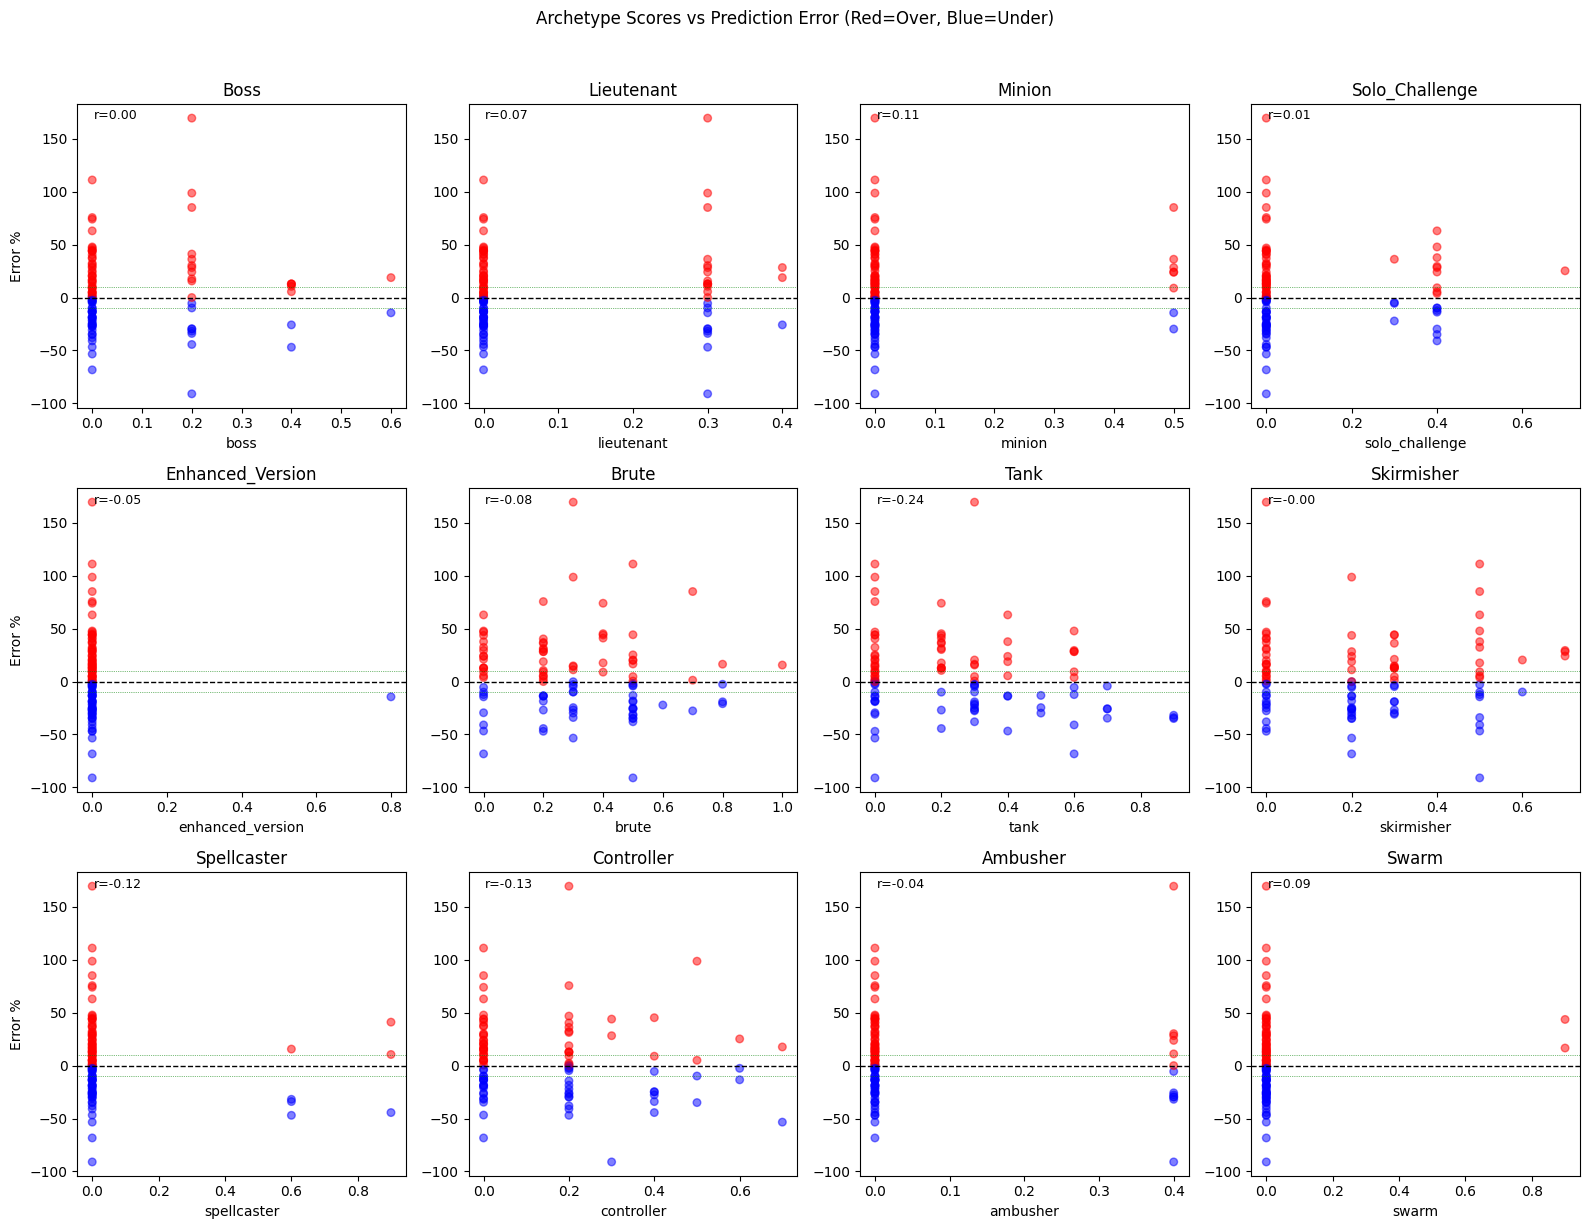


✅ Saved archetype scatter plots to ../data/cr1_4_archetype_analysis.png


In [29]:
# Visualize archetype scores vs prediction error
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(available_scores):
    ax = axes[i]
    
    # Color by prediction direction
    colors = ['red' if x > 0 else 'blue' for x in df_cr1_4['hp_delta']]
    
    ax.scatter(df_cr1_4[col], df_cr1_4['hp_delta_pct'], c=colors, alpha=0.5, s=30)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.axhline(y=10, color='green', linestyle=':', linewidth=0.5)
    ax.axhline(y=-10, color='green', linestyle=':', linewidth=0.5)
    
    ax.set_xlabel(col.replace('_score', ''))
    ax.set_ylabel('Error %' if i % 4 == 0 else '')
    ax.set_title(col.replace('_score', '').title())
    
    # Add correlation annotation
    corr = df_cr1_4[col].corr(df_cr1_4['hp_delta_pct'])
    ax.annotate(f'r={corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=9)

plt.suptitle('Archetype Scores vs Prediction Error (Red=Over, Blue=Under)', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/cr1_4_archetype_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved archetype scatter plots to {DATA_DIR}/cr1_4_archetype_analysis.png")

In [30]:
print("\n📊 WORST PREDICTIONS BY DOMINANT ARCHETYPE")
print("=" * 100)

# For each archetype with significant presence, show worst predictions
for col in available_scores:
    arch_name = col.replace('_score', '')
    high_score = df_cr1_4[df_cr1_4[col] > 0.3]
    
    if len(high_score) >= 3:
        worst_3 = high_score.nlargest(3, 'abs_pct_error')
        
        if worst_3['abs_pct_error'].mean() > 15:  # Only show if predictions are notably bad
            print(f"\n{arch_name.upper()} (score > 0.3, n={len(high_score)})")
            print("-" * 80)
            for _, row in worst_3.iterrows():
                direction = "OVER" if row['hp_delta'] > 0 else "UNDER"
                print(f"  {row['Name']:<25} CR {row['cr_numeric']:<4} Score: {row[col]:.2f}  Error: {row['hp_delta_pct']:>+6.1f}% ({direction})")


📊 WORST PREDICTIONS BY DOMINANT ARCHETYPE

BOSS (score > 0.3, n=9)
--------------------------------------------------------------------------------
  Dryad                     CR 1.0  Score: 0.40  Error:  -47.0% (UNDER)
  Bandit Captain            CR 2.0  Score: 0.40  Error:  -25.9% (UNDER)
  Knight                    CR 3.0  Score: 0.60  Error:  +18.8% (OVER)

LIEUTENANT (score > 0.3, n=3)
--------------------------------------------------------------------------------
  Veteran                   CR 3.0  Score: 0.40  Error:  +28.3% (OVER)
  Bandit Captain            CR 2.0  Score: 0.40  Error:  -25.9% (UNDER)
  Knight                    CR 3.0  Score: 0.40  Error:  +18.8% (OVER)

MINION (score > 0.3, n=8)
--------------------------------------------------------------------------------
  Giant Vulture             CR 1.0  Score: 0.50  Error:  +85.1% (OVER)
  Lion                      CR 1.0  Score: 0.50  Error:  +36.2% (OVER)
  Winter Wolf               CR 3.0  Score: 0.50  Error:  -29

In [31]:
print("\n" + "="*80)
print("📊 ARCHETYPE ANALYSIS SUMMARY")
print("="*80)

print("\n1. ARCHETYPES WITH HIGHER ERROR (harder to predict):")
for arch, corr_abs, corr_signed in sorted(correlations, key=lambda x: x[1], reverse=True)[:5]:
    if corr_abs > 0.05:
        print(f"   • {arch}: r={corr_abs:+.3f} with |error|")

print("\n2. ARCHETYPES WITH LOWER ERROR (easier to predict):")
for arch, corr_abs, corr_signed in sorted(correlations, key=lambda x: x[1])[:5]:
    if corr_abs < -0.05:
        print(f"   • {arch}: r={corr_abs:+.3f} with |error|")

print("\n3. ARCHETYPES ASSOCIATED WITH OVER-PREDICTION (less HP than expected):")
for arch, corr_abs, corr_signed in sorted(correlations, key=lambda x: x[2], reverse=True)[:5]:
    if corr_signed > 0.05:
        print(f"   • {arch}: r={corr_signed:+.3f} (model expects more HP)")

print("\n4. ARCHETYPES ASSOCIATED WITH UNDER-PREDICTION (more HP than expected):")
for arch, corr_abs, corr_signed in sorted(correlations, key=lambda x: x[2])[:5]:
    if corr_signed < -0.05:
        print(f"   • {arch}: r={corr_signed:+.3f} (model expects less HP)")

if archetype_significance:
    print("\n5. SIGNIFICANT DIFFERENCES (Good vs Bad predictions):")
    for arch, good_mean, bad_mean, diff, p_value in sorted(archetype_significance, key=lambda x: x[4])[:5]:
        direction = "higher" if diff > 0 else "lower"
        print(f"   • {arch}: Bad predictions have {direction} scores (p={p_value:.4f})")


📊 ARCHETYPE ANALYSIS SUMMARY

1. ARCHETYPES WITH HIGHER ERROR (harder to predict):
   • ambusher: r=+0.159 with |error|
   • lieutenant: r=+0.147 with |error|

2. ARCHETYPES WITH LOWER ERROR (easier to predict):
   • solo_challenge: r=-0.080 with |error|
   • enhanced_version: r=-0.053 with |error|

3. ARCHETYPES ASSOCIATED WITH OVER-PREDICTION (less HP than expected):
   • minion: r=+0.112 (model expects more HP)
   • swarm: r=+0.091 (model expects more HP)
   • lieutenant: r=+0.067 (model expects more HP)

4. ARCHETYPES ASSOCIATED WITH UNDER-PREDICTION (more HP than expected):
   • tank: r=-0.236 (model expects less HP)
   • controller: r=-0.127 (model expects less HP)
   • spellcaster: r=-0.115 (model expects less HP)
   • brute: r=-0.081 (model expects less HP)
   • enhanced_version: r=-0.054 (model expects less HP)

5. SIGNIFICANT DIFFERENCES (Good vs Bad predictions):
   • spellcaster: Bad predictions have higher scores (p=0.1357)
   • boss: Bad predictions have higher scores (p

## Part 6: Summary and Recommendations

In [32]:
print("\n" + "="*80)
print("📊 SUMMARY: CR 1-4 PREDICTION ERROR ANALYSIS")
print("="*80)

print(f"\n📈 OVERALL STATISTICS:")
print(f"   Total CR 1-4 monsters: {len(df_cr1_4)}")
print(f"   Good predictions (<10% error): {len(good_pred)} ({len(good_pred)/len(df_cr1_4)*100:.1f}%)")
print(f"   Bad predictions (>=10% error): {len(bad_pred)} ({len(bad_pred)/len(df_cr1_4)*100:.1f}%)")
print(f"   Over-predictions: {len(over_pred)} ({len(over_pred)/len(df_cr1_4)*100:.1f}%)")
print(f"   Under-predictions: {len(under_pred)} ({len(under_pred)/len(df_cr1_4)*100:.1f}%)")

print(f"\n📊 ERROR DISTRIBUTION:")
print(f"   Mean absolute error: {df_cr1_4['abs_error'].mean():.1f} HP")
print(f"   Mean absolute % error: {df_cr1_4['abs_pct_error'].mean():.1f}%")
print(f"   Median absolute % error: {df_cr1_4['abs_pct_error'].median():.1f}%")


📊 SUMMARY: CR 1-4 PREDICTION ERROR ANALYSIS

📈 OVERALL STATISTICS:
   Total CR 1-4 monsters: 99
   Good predictions (<10% error): 23 (23.2%)
   Bad predictions (>=10% error): 76 (76.8%)
   Over-predictions: 54 (54.5%)
   Under-predictions: 45 (45.5%)

📊 ERROR DISTRIBUTION:
   Mean absolute error: 11.6 HP
   Mean absolute % error: 28.1%
   Median absolute % error: 22.2%


In [33]:
print("\n🔑 KEY FINDINGS:")
print("\n1. ENGINEERED FEATURE DIFFERENCES (Good vs Bad predictions):")

if significant_features:
    for feature, good_mean, bad_mean, diff, p_value in significant_features[:5]:
        direction = "higher" if diff > 0 else "lower"
        print(f"   • {feature}: Bad predictions have {direction} values (diff: {abs(diff):.2f}, p={p_value:.4f})")

print("\n2. ENGINEERED FEATURE DIFFERENCES (Over vs Under predictions):")

if significant_direction:
    for feature, over_mean, under_mean, diff, p_value in significant_direction[:5]:
        direction = "over-predictions" if diff > 0 else "under-predictions"
        print(f"   • {feature}: More in {direction} (diff: {abs(diff):.2f}, p={p_value:.4f})")

print("\n3. PATTERN DIFFERENCES (traits/actions text):")
if pattern_differences:
    for name, good_pct, bad_pct, diff, p_value in sorted(pattern_differences, key=lambda x: abs(x[3]), reverse=True)[:5]:
        more_in = "bad" if diff > 0 else "good"
        print(f"   • {name}: More common in {more_in} predictions ({abs(diff):.1f}% diff)")


🔑 KEY FINDINGS:

1. ENGINEERED FEATURE DIFFERENCES (Good vs Bad predictions):
   • has_tremorsense: Bad predictions have lower values (diff: 0.04, p=0.0728)
   • inflicts_petrified: Bad predictions have lower values (diff: 0.04, p=0.0728)

2. ENGINEERED FEATURE DIFFERENCES (Over vs Under predictions):
   • save_dc_deviation: More in under-predictions (diff: 1.03, p=0.0000)
   • actual_hp: More in under-predictions (diff: 15.73, p=0.0003)
   • attack_deviation: More in under-predictions (diff: 0.43, p=0.0160)
   • highest_attack_bonus: More in under-predictions (diff: 0.43, p=0.0166)
   • estimated_dpr: More in under-predictions (diff: 3.14, p=0.0303)

3. PATTERN DIFFERENCES (traits/actions text):
   • true_form: More common in bad predictions (17.1% diff)
   • repeat_save: More common in good predictions (16.0% diff)
   • polymorph: More common in bad predictions (15.8% diff)
   • revert: More common in bad predictions (15.8% diff)
   • shapechange: More common in bad predictions (14.

In [34]:
print("\n💡 POTENTIAL MODEL IMPROVEMENTS:")
print("-" * 60)

# Identify patterns that might need to be parsed
print("\n1. PATTERNS THAT MAY NEED NEW FEATURES:")
for name, good_pct, bad_pct, diff, p_value in sorted(pattern_differences, key=lambda x: abs(x[3]), reverse=True)[:7]:
    if diff > 0:  # More common in bad predictions
        print(f"   • '{name}' pattern appears in {bad_pct:.1f}% of bad predictions vs {good_pct:.1f}% of good")
        print(f"     → Consider creating a feature to capture this pattern")

print("\n2. PATTERNS ASSOCIATED WITH UNDER-PREDICTION (monster has MORE HP than expected):")
for name, over_pct, under_pct, diff, p_value in sorted(pattern_direction_diff, key=lambda x: x[3])[:5]:
    if diff < -5:  # More common in under-predictions
        print(f"   • '{name}' pattern: {under_pct:.1f}% in under-pred vs {over_pct:.1f}% in over-pred")
        print(f"     → These abilities may justify MORE HP")

print("\n3. PATTERNS ASSOCIATED WITH OVER-PREDICTION (monster has LESS HP than expected):")
for name, over_pct, under_pct, diff, p_value in sorted(pattern_direction_diff, key=lambda x: x[3], reverse=True)[:5]:
    if diff > 5:  # More common in over-predictions
        print(f"   • '{name}' pattern: {over_pct:.1f}% in over-pred vs {under_pct:.1f}% in under-pred")
        print(f"     → These abilities may already be 'paid for' via HP reduction")


💡 POTENTIAL MODEL IMPROVEMENTS:
------------------------------------------------------------

1. PATTERNS THAT MAY NEED NEW FEATURES:
   • 'true_form' pattern appears in 17.1% of bad predictions vs 0.0% of good
     → Consider creating a feature to capture this pattern
   • 'polymorph' pattern appears in 15.8% of bad predictions vs 0.0% of good
     → Consider creating a feature to capture this pattern
   • 'revert' pattern appears in 15.8% of bad predictions vs 0.0% of good
     → Consider creating a feature to capture this pattern
   • 'shapechange' pattern appears in 14.5% of bad predictions vs 0.0% of good
     → Consider creating a feature to capture this pattern
   • 'multiattack' pattern appears in 36.8% of bad predictions vs 26.1% of good
     → Consider creating a feature to capture this pattern

2. PATTERNS ASSOCIATED WITH UNDER-PREDICTION (monster has MORE HP than expected):
   • 'prone_ref' pattern: 20.0% in under-pred vs 9.3% in over-pred
     → These abilities may justif

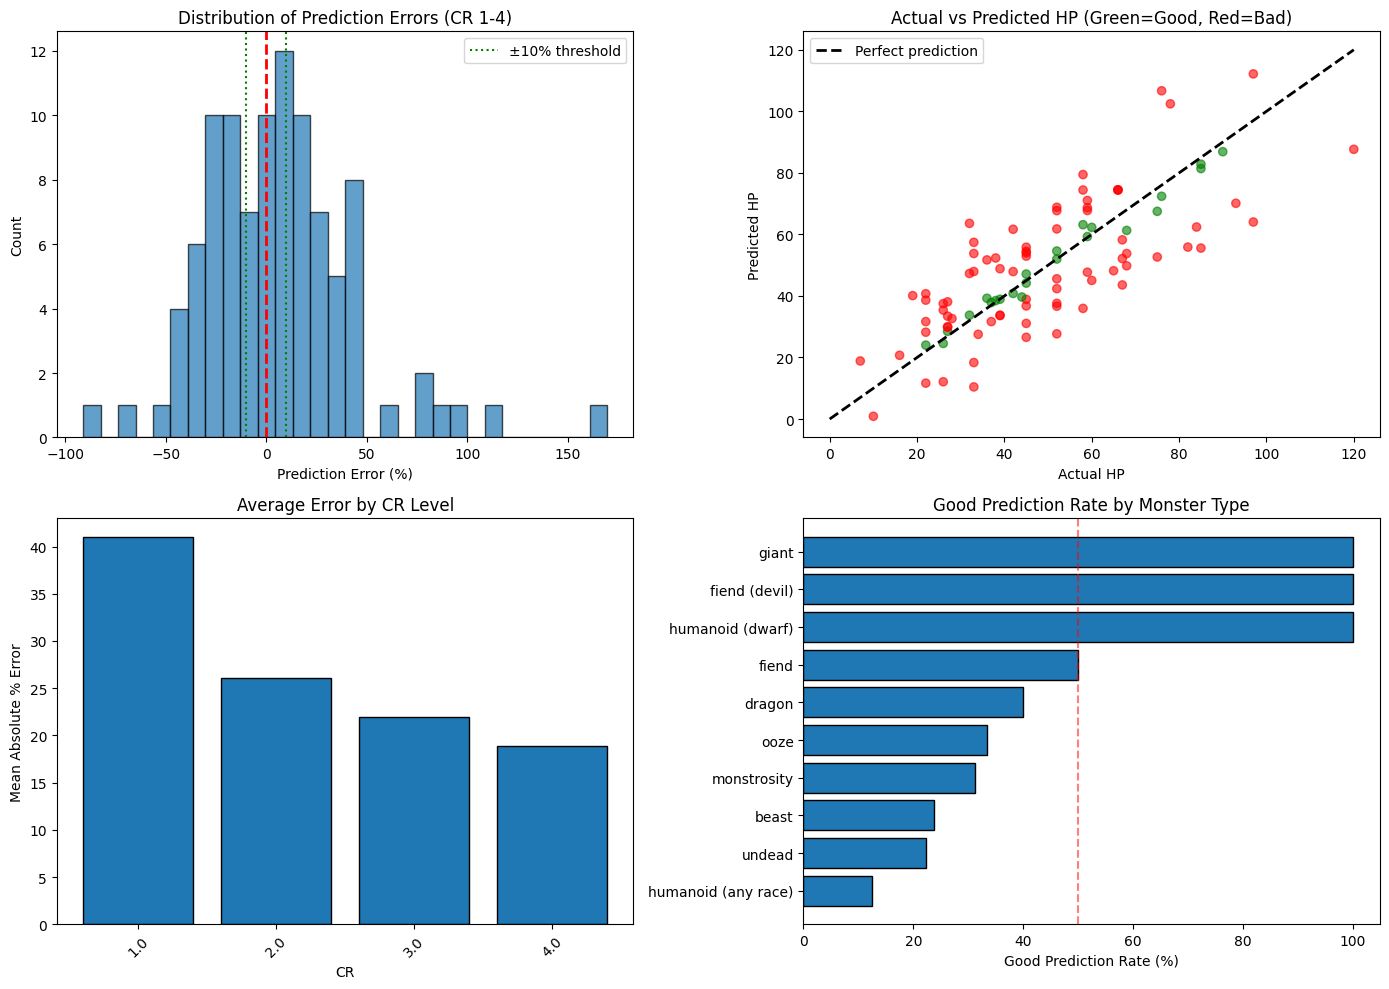


✅ Visualization saved to ../data/cr1_4_prediction_analysis.png


In [35]:
# Final visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Error distribution
ax1 = axes[0, 0]
ax1.hist(df_cr1_4['hp_delta_pct'], bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.axvline(x=-10, color='green', linestyle=':', linewidth=1.5, label='±10% threshold')
ax1.axvline(x=10, color='green', linestyle=':', linewidth=1.5)
ax1.set_xlabel('Prediction Error (%)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Prediction Errors (CR 1-4)')
ax1.legend()

# 2. Actual vs Predicted
ax2 = axes[0, 1]
colors = ['green' if q == 'Good (<10%)' else 'red' for q in df_cr1_4['prediction_quality']]
ax2.scatter(df_cr1_4['actual_hp'], df_cr1_4['predicted_hp'], c=colors, alpha=0.6)
max_hp = max(df_cr1_4['actual_hp'].max(), df_cr1_4['predicted_hp'].max())
ax2.plot([0, max_hp], [0, max_hp], 'k--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Actual HP')
ax2.set_ylabel('Predicted HP')
ax2.set_title('Actual vs Predicted HP (Green=Good, Red=Bad)')
ax2.legend()

# 3. Error by CR
ax3 = axes[1, 0]
cr_groups = df_cr1_4.groupby('cr_numeric')['abs_pct_error'].mean()
ax3.bar(cr_groups.index.astype(str), cr_groups.values, edgecolor='black')
ax3.set_xlabel('CR')
ax3.set_ylabel('Mean Absolute % Error')
ax3.set_title('Average Error by CR Level')
ax3.tick_params(axis='x', rotation=45)

# 4. Good vs Bad by type
ax4 = axes[1, 1]
type_quality = df_cr1_4.groupby('Type')['prediction_quality'].apply(
    lambda x: (x == 'Good (<10%)').mean() * 100
).sort_values()
if len(type_quality) > 10:
    type_quality = type_quality.tail(10)  # Show top 10 types
ax4.barh(type_quality.index, type_quality.values, edgecolor='black')
ax4.axvline(x=50, color='red', linestyle='--', alpha=0.5)
ax4.set_xlabel('Good Prediction Rate (%)')
ax4.set_title('Good Prediction Rate by Monster Type')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/cr1_4_prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualization saved to {DATA_DIR}/cr1_4_prediction_analysis.png")